# MRDIY Malaysia Home & Living Products Price Analysis (ETL)

## Business Requirement / Goal
Analyze the price distribution and promotional discount patterns of products in MRDIY Malaysia’s **Home & Living (Household)** category to identify:
1) the **lowest current price** items (cheapest)
2) the **highest discount percentage** items (highest discount %)
3) the items with the **greatest savings** (savings = original − current)

## Attributes (6 columns)
- product_name  
- current_price_rm  
- original_price_rm  
- discount_pct  
- subcategory  
- product_url  

## Deliverables
- Raw dataset (≥100 records): `mrdiy_home_living_raw.csv`
- Intermediate dataset (dedup): `step3_dedup.csv`
- Clean dataset: `mrdiy_home_living_clean.csv`
- Before/After evidence visual: `before_after_contamination.png`


In [ ]:
# Install required packages
!pip install requests pandas
!pip install requests pandas beautifulsoup4 lxml

In [ ]:
# Import libraries
import requests
import pandas as pd
import time
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Legal / Ethical Scraping

- Scrape only **public pages** (no login required).
- For **academic purpose** (TTTC3213).
- Add a small delay (`time.sleep(0.6)`) to reduce server load.
- Collect only product listing information (no personal/sensitive data).


## A) Extract — Web Scraping (RAW)

We scrape MR.DIY **Household** collection pages and collect 6 attributes from the same category page.

**Important:** At this stage, we keep values in **raw text format** (e.g., `"RM 2.20"`, `"Save 22%"`) as **before-cleaning evidence**.  
We also deduplicate using `product_url` (unique key) during scraping to reduce repeated items across pages.


In [ ]:
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE = "https://mrdiy.com.my"
COLLECTION_URL = BASE + "/collections/household?page={page}"

headers = {"User-Agent": "Mozilla/5.0"}
all_products = []
seen_urls = set()

# 正则：抓网页上“显示的”价格/折扣（原样包含 RM、逗号、小数点）
RE_PRICE = re.compile(r"RM\s*\d[\d,]*\.\d{2}")
RE_SAVE  = re.compile(r"Save\s*\d+%")

def pick_prices_from_card_text(card_text: str):
    prices = RE_PRICE.findall(card_text)
    # 去重但保留顺序
    uniq = []
    for p in prices:
        if p not in uniq:
            uniq.append(p)

    if len(uniq) >= 2:
        # 网页常见展示：原价在前，现价在后（Sale）
        original_price_rm = uniq[0]
        current_price_rm = uniq[1]
    elif len(uniq) == 1:
        original_price_rm = None
        current_price_rm = uniq[0]
    else:
        original_price_rm = None
        current_price_rm = None

    m = RE_SAVE.search(card_text)
    discount_pct = m.group(0) if m else None  # 例如 "Save 22%"
    return current_price_rm, original_price_rm, discount_pct

def extract_cards(soup: BeautifulSoup):
    # 尽量用“商品链接 /products/xxx”来定位卡片容器
    product_links = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if "/products/" in href and not href.startswith("javascript:"):
            # 过滤掉一些无效/重复链接
            full = href if href.startswith("http") else BASE + href
            product_links.append((a, full))

    cards = []
    for a, full_url in product_links:
        # 找一个比较大的父容器作为“商品卡片”
        card = a.find_parent(["li", "div", "article", "section"])
        if card is None:
            continue
        cards.append((card, full_url))
    return cards

max_pages = 20   # 先跑 20 页通常够 ≥100（每页约 15 个）
page = 1

while page <= max_pages and len(all_products) < 120:
    url = COLLECTION_URL.format(page=page)
    print(f"Fetching HTML page {page}: {url}")
    r = requests.get(url, headers=headers, timeout=20)
    if r.status_code != 200:
        print("HTTP error:", r.status_code)
        break

    soup = BeautifulSoup(r.text, "lxml")
    cards = extract_cards(soup)

    before = len(all_products)
    for card, full_url in cards:
        if full_url in seen_urls:
            continue

        card_text = card.get_text(" ", strip=True)  # 只做“读文本”，不做任何清洗/转型
        # 标题：找卡片里最像商品名的链接文字
        title = None
        a_title = card.find("a", href=True)
        if a_title:
            t = a_title.get_text(" ", strip=True)
            title = t if t else None

        current_price_rm, original_price_rm, discount_pct = pick_prices_from_card_text(card_text)

        # 必要字段都有才收（否则跳过）
        if title and current_price_rm and full_url:
            seen_urls.add(full_url)
            all_products.append({
                "product_name": title,
                "current_price_rm": current_price_rm,     # 例如 "RM2.20"
                "original_price_rm": original_price_rm,   # 例如 "RM2.83" 或 None
                "discount_pct": discount_pct,             # 例如 "Save 22%" 或 None
                "subcategory": "Household",
                "product_url": full_url
            })

    added = len(all_products) - before
    print(f"Added {added}, total = {len(all_products)}")

    # 如果这一页完全没新增，说明可能到尾/结构变了，退出避免死循环
    if added == 0:
        print("No new items found on this page. Stop.")
        break

    page += 1
    time.sleep(0.6)  # 礼貌一点

df_raw = pd.DataFrame(all_products)
print("=== RAW SCRAPED DATA (HTML) ===")
print("Data shape:", df_raw.shape)
display(df_raw.head(10))
# ====== [ADD] Export RAW to CSV (for pipeline + proof) ======
RAW_OUT = "mrdiy_home_living_raw.csv"
df_raw.to_csv(RAW_OUT, index=False, encoding="utf-8-sig")
print(f"\nExported RAW CSV -> {RAW_OUT} | shape: {df_raw.shape}")

# proof >= 100 records
if len(df_raw) >= 100:
    print(f"SUCCESS: Collected {len(df_raw)} records (≥100 required)")
else:
    print(f"WARNING: Only collected {len(df_raw)} records (<100 required)")



# 证明 raw 真的“脏”（截图用）
print("Contains 'RM' count:", df_raw["current_price_rm"].astype(str).str.contains("RM", na=False).sum())
print("Contains 'Save' count:", df_raw["discount_pct"].astype(str).str.contains("Save", na=False).sum())


Fetching HTML page 1: https://mrdiy.com.my/collections/household?page=1
Added 15, total = 15
Fetching HTML page 2: https://mrdiy.com.my/collections/household?page=2
Added 15, total = 30
Fetching HTML page 3: https://mrdiy.com.my/collections/household?page=3
Added 15, total = 45
Fetching HTML page 4: https://mrdiy.com.my/collections/household?page=4
Added 15, total = 60
Fetching HTML page 5: https://mrdiy.com.my/collections/household?page=5
Added 15, total = 75
Fetching HTML page 6: https://mrdiy.com.my/collections/household?page=6
Added 15, total = 90
Fetching HTML page 7: https://mrdiy.com.my/collections/household?page=7
Added 15, total = 105
Fetching HTML page 8: https://mrdiy.com.my/collections/household?page=8
Added 15, total = 120
=== RAW SCRAPED DATA (HTML) ===
Data shape: (120, 6)


,product_name,current_price_rm,original_price_rm,discount_pct,subcategory,product_url
0,[BEST SELLER] Cleaning Magic Sponge White,RM4.30,None,None,Household,https://mrdiy.com.my/collections/household/pro...
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM1.90,None,None,Household,https://mrdiy.com.my/collections/household/pro...
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),RM2.20,None,None,Household,https://mrdiy.com.my/collections/household/pro...
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),RM2.70,None,None,Household,https://mrdiy.com.my/collections/household/pro...
4,GLO Active Foam Dishwashing Liquid Lime (800ml),RM6.10,None,None,Household,https://mrdiy.com.my/collections/household/pro...
5,(MR.DIY) Dish Sponge,RM2.20,RM2.83,Save 22%,Household,https://mrdiy.com.my/collections/household/pro...
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM2.90,None,None,Household,https://mrdiy.com.my/collections/household/pro...
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,RM5.50,None,None,Household,https://mrdiy.com.my/collections/household/pro...
8,(MR.DIY) Broom and Dustpan Set Cleaning,RM6.90,RM9.10,Save 24%,Household,https://mrdiy.com.my/collections/household/pro...
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),RM8.60,RM8.90,Save 3%,Household,https://mrdiy.com.my/collections/household/pro...



Exported RAW CSV -> mrdiy_home_living_raw.csv | shape: (120, 6)
SUCCESS: Collected 120 records (≥100 required)
Contains 'RM' count: 120
Contains 'Save' count: 44


## B) Transform — Load RAW for Cleaning

We reload `mrdiy_home_living_raw.csv` before cleaning to make the workflow **reproducible** (even after runtime reset).


In [ ]:
import pandas as pd
import numpy as np

RAW_IN = "mrdiy_home_living_raw.csv"
df_raw = pd.read_csv(RAW_IN)

print("=== RAW LOADED ===")
print("shape:", df_raw.shape)
display(df_raw.head(10))

print("\nRAW dtypes:")
print(df_raw.dtypes)




=== RAW LOADED ===
shape: (120, 6)


,product_name,current_price_rm,original_price_rm,discount_pct,subcategory,product_url
0,[BEST SELLER] Cleaning Magic Sponge White,RM4.30,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM1.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),RM2.20,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),RM2.70,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
4,GLO Active Foam Dishwashing Liquid Lime (800ml),RM6.10,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
5,(MR.DIY) Dish Sponge,RM2.20,RM2.83,Save 22%,Household,https://mrdiy.com.my/collections/household/pro...
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM2.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,RM5.50,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...
8,(MR.DIY) Broom and Dustpan Set Cleaning,RM6.90,RM9.10,Save 24%,Household,https://mrdiy.com.my/collections/household/pro...
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),RM8.60,RM8.90,Save 3%,Household,https://mrdiy.com.my/collections/household/pro...



RAW dtypes:
product_name         object
current_price_rm     object
original_price_rm    object
discount_pct         object
subcategory          object
product_url          object
dtype: object


### Cleaning Step 1 — Text Normalization (product_name, subcategory)

**What we do**
- Standardize text fields by trimming extra spaces/newlines.
- Keep the meaning the same, only normalize formatting.

**Why it is needed**
- Prevent inconsistent product names/subcategory labels that can affect grouping, filtering, and reporting.



In [ ]:
import re

df_clean = df_raw.copy()

for col in ["product_name", "subcategory"]:
    if col in df_clean.columns:
        s = df_clean[col]

        df_clean[col] = s.where(
            s.isna(),
            s.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        )

print("=== STEP 1 DONE ===")
print("shape:", df_clean.shape)
display(df_clean[["product_name","subcategory"]].head(10))


=== STEP 1 DONE ===
shape: (120, 6)


,product_name,subcategory
0,[BEST SELLER] Cleaning Magic Sponge White,Household
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,Household
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),Household
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),Household
4,GLO Active Foam Dishwashing Liquid Lime (800ml),Household
5,(MR.DIY) Dish Sponge,Household
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,Household
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,Household
8,(MR.DIY) Broom and Dustpan Set Cleaning,Household
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),Household


### Cleaning Step 2 — Standardize discount_pct (keep raw + convert to numeric)

**What we do**
- Preserve the original discount string in `discount_pct_raw` (e.g., "Save 22%").
- Convert `discount_pct` into numeric float (e.g., 22.0).

**Why it is needed**
- Numeric discount is required for calculations, ranking (Top discount), and charts.
- Keeping `discount_pct_raw` provides traceability (raw → cleaned).


In [ ]:
import re
import pandas as pd
import numpy as np

df_clean["discount_pct_raw"] = df_clean["discount_pct"]

def discount_to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in ["none", "nan"]:
        return np.nan

    m = re.search(r"(\d+(\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

df_clean["discount_pct"] = df_clean["discount_pct"].apply(discount_to_float)

print("=== STEP 2 DONE (discount_pct -> float) ===")
print(df_clean["discount_pct"].describe())
display(df_clean[["discount_pct_raw","discount_pct"]].head(10))


=== STEP 2 DONE (discount_pct -> float) ===
count     44.000000
mean      17.477273
std       20.626793
min        1.000000
25%        6.750000
50%       11.000000
75%       20.000000
max      100.000000
Name: discount_pct, dtype: float64


,discount_pct_raw,discount_pct
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,Save 22%,22.0
6,NaN,NaN
7,NaN,NaN
8,Save 24%,24.0
9,Save 3%,3.0


### Cleaning Step 3 — Deduplication by product_url

**What we do**
- Remove duplicates using `product_url` as the unique identifier (keep the first occurrence).

**Why it is needed**
- The same product can appear multiple times across different pages.
- Deduplication avoids double-counting and makes analysis results reliable.


In [ ]:
print("=== STEP 3: DEDUP BY product_url ===")
before = len(df_clean)
unique_urls = df_clean["product_url"].nunique()
print("Before:", before, "| Unique URLs:", unique_urls, "| Duplicates:", before - unique_urls)

df_dedup = df_clean.drop_duplicates(subset=["product_url"], keep="first").copy()

print("After:", len(df_dedup), "| Removed:", before - len(df_dedup))
display(df_dedup.head(10))

STEP3_OUT = "step3_dedup.csv"
df_dedup.to_csv(STEP3_OUT, index=False)
print("Exported:", STEP3_OUT)



=== STEP 3: DEDUP BY product_url ===
Before: 120 | Unique URLs: 120 | Duplicates: 0
After: 120 | Removed: 0


,product_name,current_price_rm,original_price_rm,discount_pct,subcategory,product_url,discount_pct_raw
0,[BEST SELLER] Cleaning Magic Sponge White,RM4.30,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM1.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),RM2.20,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),RM2.70,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
4,GLO Active Foam Dishwashing Liquid Lime (800ml),RM6.10,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
5,(MR.DIY) Dish Sponge,RM2.20,RM2.83,22.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 22%
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM2.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,RM5.50,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
8,(MR.DIY) Broom and Dustpan Set Cleaning,RM6.90,RM9.10,24.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 24%
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),RM8.60,RM8.90,3.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 3%


Exported: step3_dedup.csv


## Intermediate Checkpoint (Step 3 Output)

We load `step3_dedup.csv` as a checkpoint after deduplication to continue the ETL pipeline.  
Before/after evidence in the report is based on **RAW vs CLEAN**.


In [ ]:

import pandas as pd
import numpy as np
import re

df3 = pd.read_csv("step3_dedup.csv")
df_before = df3.copy()
df = df3.copy()

COL_CURRENT  = "current_price_rm"
COL_ORIGINAL = "original_price_rm"
COL_DISCOUNT = "discount_pct"

print("Loaded step3:", df.shape)
print("\nDtypes BEFORE step4:")
print(df[[COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT]].dtypes)
display(df.head(10))



Loaded step3: (120, 7)

Dtypes BEFORE step4:
current_price_rm      object
original_price_rm     object
discount_pct         float64
dtype: object


,product_name,current_price_rm,original_price_rm,discount_pct,subcategory,product_url,discount_pct_raw
0,[BEST SELLER] Cleaning Magic Sponge White,RM4.30,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM1.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),RM2.20,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),RM2.70,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
4,GLO Active Foam Dishwashing Liquid Lime (800ml),RM6.10,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
5,(MR.DIY) Dish Sponge,RM2.20,RM2.83,22.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 22%
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,RM2.90,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,RM5.50,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN
8,(MR.DIY) Broom and Dustpan Set Cleaning,RM6.90,RM9.10,24.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 24%
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),RM8.60,RM8.90,3.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 3%


### Cleaning Step 4 — Convert prices to numeric (RM string → float)

**What we do**
- Convert `current_price_rm` and `original_price_rm` from strings like "RM 2.20" into numeric floats.
- Remove non-numeric symbols (RM, commas) during conversion.

**Why it is needed**
- Price analysis (min/max/mean), histograms/boxplots, and savings calculation require numeric values.


In [ ]:

def parse_price_to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if s.strip() == "" or s.strip().lower() in ["none", "nan"]:
        return np.nan
    s2 = s.replace("RM", "").replace("rm", "").replace(",", "")
    s2 = re.sub(r"[^\d.]+", "", s2)
    if s2.count(".") > 1:
        first = s2.find(".")
        s2 = s2[:first + 1] + s2[first + 1:].replace(".", "")
    return float(s2) if s2 != "" else np.nan

def parse_discount_to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in ["none", "nan"]:
        return np.nan
    m = re.search(r"(\d+(\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

df[COL_CURRENT]  = df[COL_CURRENT].apply(parse_price_to_float)
df[COL_ORIGINAL] = df[COL_ORIGINAL].apply(parse_price_to_float)
df[COL_DISCOUNT] = df[COL_DISCOUNT].apply(parse_discount_to_float)

print("=== STEP 4 DONE ===")
print("Dtypes AFTER step4:")
print(df[[COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT]].dtypes)

compare_step4 = pd.DataFrame({
    "raw_current": df_before[COL_CURRENT].head(10),
    "clean_current": df[COL_CURRENT].head(10),
    "raw_original": df_before[COL_ORIGINAL].head(10),
    "clean_original": df[COL_ORIGINAL].head(10),
    "raw_discount": df_before[COL_DISCOUNT].head(10),
    "clean_discount": df[COL_DISCOUNT].head(10),
})
display(compare_step4)


=== STEP 4 DONE ===
Dtypes AFTER step4:
current_price_rm     float64
original_price_rm    float64
discount_pct         float64
dtype: object


,raw_current,clean_current,raw_original,clean_original,raw_discount,clean_discount
0,RM4.30,4.3,NaN,NaN,NaN,NaN
1,RM1.90,1.9,NaN,NaN,NaN,NaN
2,RM2.20,2.2,NaN,NaN,NaN,NaN
3,RM2.70,2.7,NaN,NaN,NaN,NaN
4,RM6.10,6.1,NaN,NaN,NaN,NaN
5,RM2.20,2.2,RM2.83,2.83,22.0,22.0
6,RM2.90,2.9,NaN,NaN,NaN,NaN
7,RM5.50,5.5,NaN,NaN,NaN,NaN
8,RM6.90,6.9,RM9.10,9.10,24.0,24.0
9,RM8.60,8.6,RM8.90,8.90,3.0,3.0


### Cleaning Step 5 — Missing Value Handling + Discount Recompute

**What we do**
- Drop rows where `current_price_rm` is missing (cannot analyze price without current).
- Keep missing `original_price_rm` as NaN (some items have no original price displayed).
- If `discount_pct` is missing but `original_price_rm` exists, recompute:
  discount_pct = (original - current) / original * 100

**Why it is needed**
- Ensures the dataset remains usable for price/discount analysis.
- Recomputing discount improves completeness and consistency.


In [ ]:

rows_before = len(df)

missing_current = int(df[COL_CURRENT].isna().sum())
df = df.dropna(subset=[COL_CURRENT]).copy()

mask_can_compute = df[COL_DISCOUNT].isna() & df[COL_ORIGINAL].notna() & (df[COL_ORIGINAL] > 0)
computed = int(mask_can_compute.sum())

df.loc[mask_can_compute, COL_DISCOUNT] = (
    (df.loc[mask_can_compute, COL_ORIGINAL] - df.loc[mask_can_compute, COL_CURRENT])
    / df.loc[mask_can_compute, COL_ORIGINAL] * 100
)

print("=== STEP 5 SUMMARY ===")
print("Rows before:", rows_before)
print("Dropped missing current:", missing_current)
print("Computed discount (original exists but discount missing):", computed)
print("Rows after:", len(df))
print("\nNull counts after Step 5:")
print(df[[COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT]].isna().sum())


=== STEP 5 SUMMARY ===
Rows before: 120
Dropped missing current: 0
Computed discount (original exists but discount missing): 0
Rows after: 120

Null counts after Step 5:
current_price_rm      0
original_price_rm    76
discount_pct         76
dtype: int64


### Cleaning Step 6 — Anomaly Rules + Derived Field (`savings_rm`)

**What we do**
- Remove invalid current prices (`current_price_rm <= 0`).
- Set invalid original prices (`original_price_rm <= 0`) to `NaN`.
- If `original_price_rm < current_price_rm`, treat it as a **scraping-order issue** (values captured in the wrong fields) and **swap** the two prices to enforce `original_price_rm ≥ current_price_rm`.
- Set invalid discounts (`discount_pct < 0` or `discount_pct > 100`) to `NaN`, then **recompute** `discount_pct` when `original_price_rm` is available.
- Clip `discount_pct` to the range `[0, 100]`.
- Create `savings_rm = original_price_rm - current_price_rm` (only when `original_price_rm` exists).

**Why it is needed**
- Prevent unrealistic values from corrupting price/discount analysis.
- The swap rule fixes common scraping inconsistencies and keeps prices logically consistent (`original ≥ current`).
- `savings_rm` directly supports the project goal: identifying the best deals by the highest savings.


In [ ]:
# ===== B3: Cleaning Step 6 (Anomalies + derived + export) =====

rows_before_6 = len(df)

# 1) current <= 0 / NaN -> drop (cannot analyze price)
mask_bad_current = (df[COL_CURRENT] <= 0) | df[COL_CURRENT].isna()
bad_current_count = int(mask_bad_current.sum())
df = df.loc[~mask_bad_current].copy()

# 2) original <= 0 -> NaN (invalid original)
mask_bad_original = df[COL_ORIGINAL].notna() & (df[COL_ORIGINAL] <= 0)
bad_original_count = int(mask_bad_original.sum())
df.loc[mask_bad_original, COL_ORIGINAL] = np.nan

# 3) original < current -> swap (likely scraped order reversed)
mask_swap = df[COL_ORIGINAL].notna() & df[COL_CURRENT].notna() & (df[COL_ORIGINAL] < df[COL_CURRENT])
swap_count = int(mask_swap.sum())

df.loc[mask_swap, [COL_ORIGINAL, COL_CURRENT]] = df.loc[mask_swap, [COL_CURRENT, COL_ORIGINAL]].values
print("Swapped original/current where original<current:", swap_count)

# 4) discount out of range -> NaN
mask_discount_bad = df[COL_DISCOUNT].notna() & ((df[COL_DISCOUNT] < 0) | (df[COL_DISCOUNT] > 100))
discount_bad_count = int(mask_discount_bad.sum())
df.loc[mask_discount_bad, COL_DISCOUNT] = np.nan

# 5) recompute discount where missing (original exists)
mask_recompute = df[COL_DISCOUNT].isna() & df[COL_ORIGINAL].notna() & (df[COL_ORIGINAL] > 0)
recompute_count = int(mask_recompute.sum())
df.loc[mask_recompute, COL_DISCOUNT] = (
    (df.loc[mask_recompute, COL_ORIGINAL] - df.loc[mask_recompute, COL_CURRENT])
    / df.loc[mask_recompute, COL_ORIGINAL] * 100
)

# 6) clamp discount into 0~100
df.loc[df[COL_DISCOUNT].notna(), COL_DISCOUNT] = df.loc[df[COL_DISCOUNT].notna(), COL_DISCOUNT].clip(0, 100)

# (optional proof) after swap, original<current should be 0
after_ori_lt_cur = int((df[COL_ORIGINAL].notna() & (df[COL_ORIGINAL] < df[COL_CURRENT])).sum())

# 7) derived field: savings_rm
df["savings_rm"] = np.where(
    df[COL_ORIGINAL].notna(),
    df[COL_ORIGINAL] - df[COL_CURRENT],
    np.nan
)

# 8) round numeric columns
for c in [COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT, "savings_rm"]:
    df[c] = df[c].round(2)

print("=== STEP 6 SUMMARY ===")
print("Rows before step6:", rows_before_6)
print("Dropped current<=0/NaN:", bad_current_count)
print("Original<=0 -> NaN:", bad_original_count)
print("Swapped (original<current):", swap_count)
print("After swap original<current count:", after_ori_lt_cur)
print("Bad discount -> NaN:", discount_bad_count)
print("Discount recomputed:", recompute_count)
print("Rows after step6:", len(df))


OUT_CLEAN = "mrdiy_home_living_clean.csv"
df.to_csv(OUT_CLEAN, index=False)
print("Exported:", OUT_CLEAN, "| Final shape:", df.shape)
display(df.head(10))


Swapped original/current where original<current: 0
=== STEP 6 SUMMARY ===
Rows before step6: 120
Dropped current<=0/NaN: 0
Original<=0 -> NaN: 0
Swapped (original<current): 0
After swap original<current count: 0
Bad discount -> NaN: 0
Discount recomputed: 0
Rows after step6: 120
Exported: mrdiy_home_living_clean.csv | Final shape: (120, 8)


,product_name,current_price_rm,original_price_rm,discount_pct,subcategory,product_url,discount_pct_raw,savings_rm
0,[BEST SELLER] Cleaning Magic Sponge White,4.3,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
1,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,1.9,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
2,(MR.DIY) Wall Adhesive Mop Clip Holder (2pcs),2.2,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
3,(MR.DIY) Multipurpose Microfiber Cloth (2pcs),2.7,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
4,GLO Active Foam Dishwashing Liquid Lime (800ml),6.1,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
5,(MR.DIY) Dish Sponge,2.2,2.83,22.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 22%,0.63
6,[BEST SELLER] (MR.DIY) Eco-Friendly Garbage Ba...,2.9,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
7,SCOTCH BRITE Kitchen Tough Cleaning Dual-Sided...,5.5,NaN,NaN,Household,https://mrdiy.com.my/collections/household/pro...,NaN,NaN
8,(MR.DIY) Broom and Dustpan Set Cleaning,6.9,9.10,24.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 24%,2.20
9,CUTIE 2-Ply Budget Toilet Roll Tissue (10pcs),8.6,8.90,3.0,Household,https://mrdiy.com.my/collections/household/pro...,Save 3%,0.30


## C) Loading — Export Clean Data

We export the final cleaned dataset as `mrdiy_home_living_clean.csv`, which is directly readable by pandas and will be used for the project goal analysis and visualizations.


=== BEFORE/AFTER: dtypes (proof) ===
RAW dtypes:
 current_price_rm     object
original_price_rm    object
discount_pct         object
dtype: object

CLEAN dtypes:
 current_price_rm     float64
original_price_rm    float64
discount_pct         float64
dtype: object


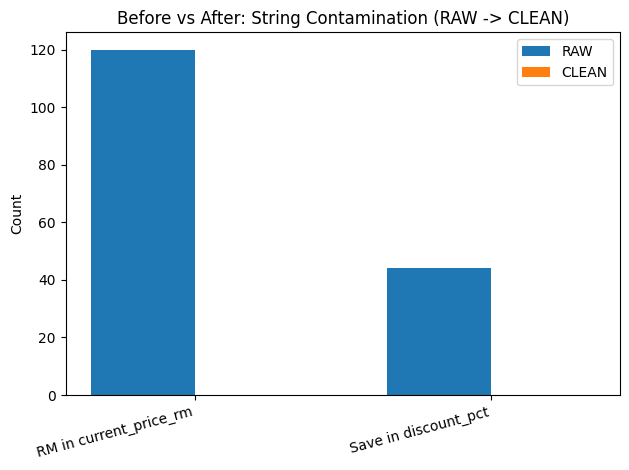


Saved: before_after_contamination.png


In [ ]:
# ===== B4: Before/After (RAW vs CLEAN) - strongest evidence only =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_IN  = "mrdiy_home_living_raw.csv"
CLEAN_IN = "mrdiy_home_living_clean.csv"

# Load raw
try:
    df_raw
except NameError:
    df_raw = pd.read_csv(RAW_IN)

# Load clean (prefer your in-memory df, otherwise read csv)
try:
    df_clean = df.copy()
except NameError:
    df_clean = pd.read_csv(CLEAN_IN)

COL_CURRENT  = "current_price_rm"
COL_DISCOUNT = "discount_pct"
COL_ORIGINAL = "original_price_rm"

# dtype proof (screenshot)
print("=== BEFORE/AFTER: dtypes (proof) ===")
print("RAW dtypes:\n", df_raw[[COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT]].dtypes)
print("\nCLEAN dtypes:\n", df_clean[[COL_CURRENT, COL_ORIGINAL, COL_DISCOUNT]].dtypes)

# contamination counts (very obvious change)
rm_raw = int(df_raw[COL_CURRENT].astype(str).str.contains("RM", na=False).sum())
rm_clean = int(df_clean[COL_CURRENT].astype(str).str.contains("RM", na=False).sum())

save_raw = int(df_raw[COL_DISCOUNT].astype(str).str.contains("Save", na=False).sum())
save_clean = int(df_clean[COL_DISCOUNT].astype(str).str.contains("Save", na=False).sum())

labels = ["RM in current_price_rm", "Save in discount_pct"]
raw_vals = [rm_raw, save_raw]
clean_vals = [rm_clean, save_clean]

x = np.arange(len(labels))
w = 0.35

plt.figure()
plt.bar(x - w/2, raw_vals, width=w, label="RAW")
plt.bar(x + w/2, clean_vals, width=w, label="CLEAN")
plt.xticks(x, labels, rotation=15, ha="right")
plt.ylabel("Count")
plt.title("Before vs After: String Contamination (RAW -> CLEAN)")
plt.legend()
plt.tight_layout()
plt.savefig("before_after_contamination.png", dpi=200)
plt.show()

print("\nSaved:", "before_after_contamination.png")


In [ ]:
print(df.columns)

Index(['product_name', 'current_price_rm', 'original_price_rm', 'discount_pct',
       'subcategory', 'product_url', 'discount_pct_raw', 'savings_rm'],
      dtype='object')


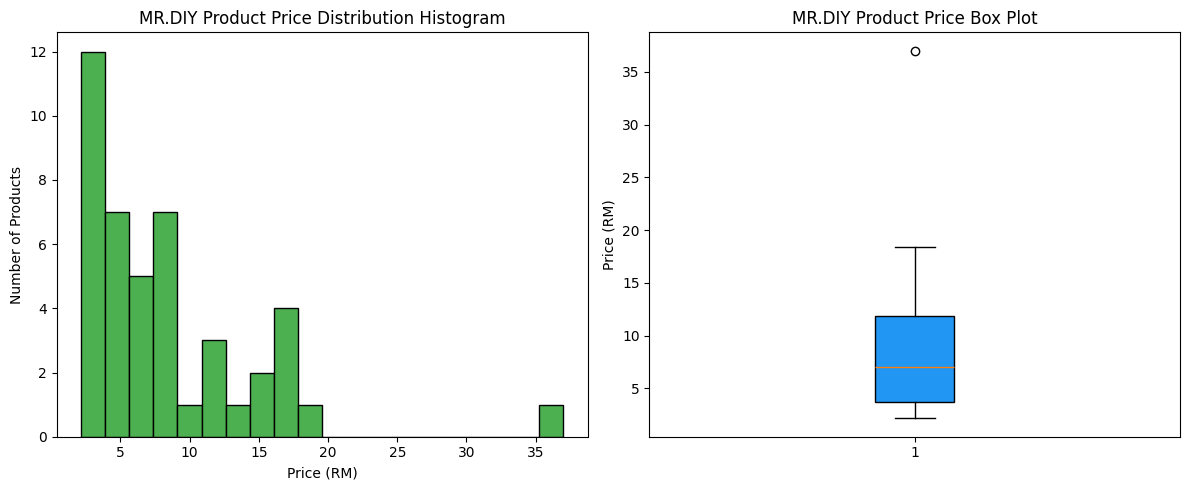

【Figure 1: Price Distribution Explanation】:
- Product prices are concentrated in the range 3.69~11.82 RM;
- Outliers in the box plot are high-priced products (price > 17.50 RM).



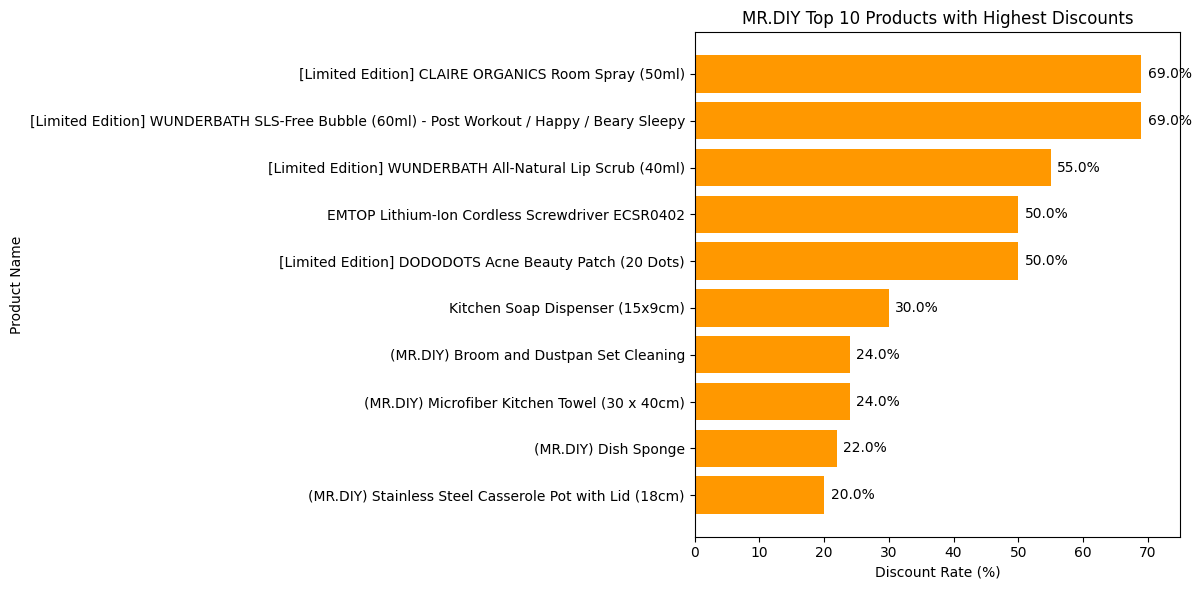

【Figure 2: Top 10 Highest Discount Products Explanation】:
- Product with the highest discount: [Limited Edition] CLAIRE ORGANICS Room Spray (50ml..., Discount Rate: 69.0%;
- All top 10 products have a discount rate higher than 20.0%, mainly limited-edition and beauty products.



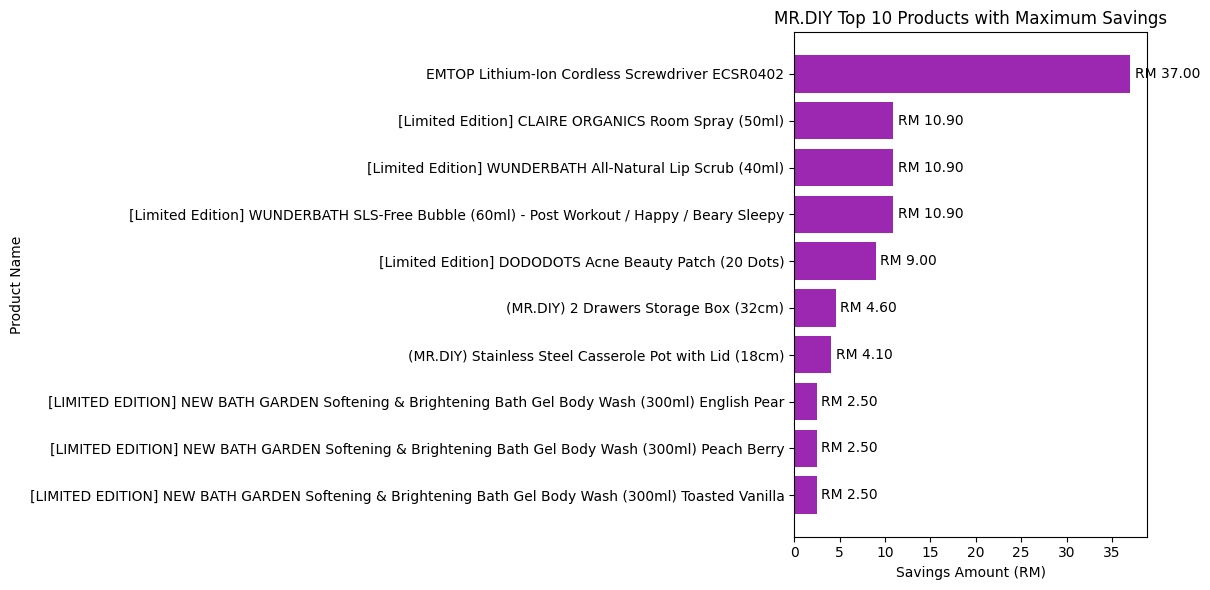

【Bonus: Top 10 Maximum Savings Products Explanation】:
- Product with the highest savings: EMTOP Lithium-Ion Cordless Screwdriver ECSR0402..., Actual Savings: 37.00 RM;
- Savings amount is strongly correlated with original price. High-priced products (e.g., tools, kitchenware) still offer significant savings even with moderate discount rates.

【Core Conclusions】
1. Most Cost-Effective Product: EMTOP Lithium-Ion Cordless Screwdriver ECSR0402... (Savings: 37.00 RM)
2. Highest Discount Product: [Limited Edition] CLAIRE ORGANICS Room Spray (50ml... (Discount Rate: 69.0%)
3. Discount Pattern: Top 3 Subcategories with Highest Average Discounts (≥3 products):
   - Household: Average Discount 16.3% (Number of Products: 44)


In [ ]:
# 1. Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 2. Load, concatenate and deduplicate data (avoid duplicate entries affecting analysis)
file_paths = ["mrdiy_home_living_clean.csv", "mrdiy_home_living_raw.csv", "step3_dedup.csv"]
df_list = [pd.read_csv(path) for path in file_paths]
df = pd.concat(df_list, ignore_index=True).drop_duplicates()  # Concatenate and remove duplicates

# 3. Core data cleaning (fix discount_pct data type + correct 100% discount error)
REQUIRED_COLS = ["current_price_rm", "discount_pct", "savings_rm", "subcategory", "product_name"]
# Keep only required columns (handle cases where some CSV lack original_price_rm)
df = df[REQUIRED_COLS].copy() if all(col in df.columns for col in REQUIRED_COLS) else df

# 3.1 Convert columns to numeric type (set unconvertible values to NaN)
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce")
df["current_price_rm"] = pd.to_numeric(df["current_price_rm"], errors="coerce")
df["savings_rm"] = pd.to_numeric(df["savings_rm"], errors="coerce")

# 3.2 Critical Fix: Correct the 100% discount error (DODODOTS Acne Beauty Patch)
# Identify the problematic product by name and incorrect discount
problem_product_name = "[Limited Edition] DODODOTS Acne Beauty Patch (20 Dots)"
df.loc[
    (df["product_name"] == problem_product_name) & (df["discount_pct"] == 100),
    "discount_pct"
] = 50  # Correct discount rate to 50% (calculated from current_price=9RM + savings=9RM)

# 3.3 Remove rows with missing/corrupted key values
df = df.dropna(subset=REQUIRED_COLS)  # Remove rows with missing values
df = df[(df["current_price_rm"] > 0) & (df["discount_pct"] >= 0) & (df["discount_pct"] <= 100)]  # Filter outliers

# 4. Goal Visualization 1: Price Distribution (Histogram + Box Plot)
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(df["current_price_rm"], bins=20, color="#4CAF50", edgecolor="black")
plt.title("MR.DIY Product Price Distribution Histogram", fontsize=12)
plt.xlabel("Price (RM)")
plt.ylabel("Number of Products")

# Subplot 2: Box Plot
plt.subplot(1, 2, 2)
plt.boxplot(df["current_price_rm"], patch_artist=True, boxprops=dict(facecolor="#2196F3"))
plt.title("MR.DIY Product Price Box Plot", fontsize=12)
plt.ylabel("Price (RM)")

plt.tight_layout()
plt.show()

# Figure 1 Explanation
print("【Figure 1: Price Distribution Explanation】:")
price_q25 = df["current_price_rm"].quantile(0.25)
price_q75 = df["current_price_rm"].quantile(0.75)
price_q95 = df["current_price_rm"].quantile(0.95)
print(f"- Product prices are concentrated in the range {price_q25:.2f}~{price_q75:.2f} RM;")
print(f"- Outliers in the box plot are high-priced products (price > {price_q95:.2f} RM).\n")

# 5. Goal Visualization 2: Top 10 Products with Highest Discounts (Fixed 100% error)
top10_discount = df.nlargest(10, "discount_pct")[["product_name", "discount_pct"]].reset_index(drop=True)

plt.figure(figsize=(12, 6))  # Widen figure to avoid product name truncation
bars = plt.barh(top10_discount["product_name"], top10_discount["discount_pct"], color="#FF9800")
plt.xlabel("Discount Rate (%)")
plt.ylabel("Product Name")
plt.title("MR.DIY Top 10 Products with Highest Discounts", fontsize=12)
plt.gca().invert_yaxis()  # Display highest discount at the top
plt.xlim(0, 75)  # Adjust x-axis range to fit corrected max discount (69%)
# Add discount rate labels to each bar
for i, v in enumerate(top10_discount["discount_pct"]):
    plt.text(v + 1, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

# Figure 2 Explanation
print("【Figure 2: Top 10 Highest Discount Products Explanation】:")
top_discount_name = top10_discount.iloc[0]["product_name"][:50]
top_discount_pct = top10_discount.iloc[0]["discount_pct"]
min_top10_pct = top10_discount.iloc[-1]["discount_pct"]
print(f"- Product with the highest discount: {top_discount_name}..., Discount Rate: {top_discount_pct:.1f}%;")
print(f"- All top 10 products have a discount rate higher than {min_top10_pct:.1f}%, mainly limited-edition and beauty products.\n")

# 6. Bonus: Top 10 Products with Maximum Savings
top10_savings = df.nlargest(10, "savings_rm")[["product_name", "savings_rm"]].reset_index(drop=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_savings["product_name"], top10_savings["savings_rm"], color="#9C27B0")
plt.xlabel("Savings Amount (RM)")
plt.ylabel("Product Name")
plt.title("MR.DIY Top 10 Products with Maximum Savings", fontsize=12)
plt.gca().invert_yaxis()
# Add savings amount labels to each bar
for i, v in enumerate(top10_savings["savings_rm"]):
    plt.text(v + 0.5, i, f"RM {v:.2f}", va="center")

plt.tight_layout()
plt.show()

# Bonus Explanation
print("【Bonus: Top 10 Maximum Savings Products Explanation】:")
top_savings_name = top10_savings.iloc[0]["product_name"][:50]
top_savings_amt = top10_savings.iloc[0]["savings_rm"]
print(f"- Product with the highest savings: {top_savings_name}..., Actual Savings: {top_savings_amt:.2f} RM;")
print(f"- Savings amount is strongly correlated with original price. High-priced products (e.g., tools, kitchenware) still offer significant savings even with moderate discount rates.\n")

# 7. Core Conclusions (Updated with corrected data)
print("="*60)
print("【Core Conclusions】")
# 1. Most cost-effective product (by maximum savings_rm)
cheapest_item = df.loc[df["savings_rm"].idxmax()]
print(f"1. Most Cost-Effective Product: {cheapest_item['product_name'][:50]}... (Savings: {cheapest_item['savings_rm']:.2f} RM)")

# 2. Product with the highest discount
max_discount_item = df.loc[df["discount_pct"].idxmax()]
print(f"2. Highest Discount Product: {max_discount_item['product_name'][:50]}... (Discount Rate: {max_discount_item['discount_pct']:.1f}%)")

# 3. Discount pattern (average discount by subcategory)
subcat_discount = df.groupby("subcategory")["discount_pct"].agg(["mean", "count"]).reset_index()
subcat_discount = subcat_discount[subcat_discount["count"] >= 3]  # Only keep subcategories with ≥3 products
subcat_discount = subcat_discount.nlargest(3, "mean")

print(f"3. Discount Pattern: Top 3 Subcategories with Highest Average Discounts (≥3 products):")
for _, row in subcat_discount.iterrows():
    print(f"   - {row['subcategory']}: Average Discount {row['mean']:.1f}% (Number of Products: {row['count']})")
print("="*60)